## 1. Inicializacion

In [53]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score,GridSearchCV, train_test_split, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
import sklearn.metrics as metrics

In [2]:
contract = pd.read_csv('/datasets/final_provider/contract.csv')
personal = pd.read_csv('/datasets/final_provider/personal.csv')
internet = pd.read_csv('/datasets/final_provider/internet.csv')
phone = pd.read_csv('/datasets/final_provider/phone.csv')

Exploracion de datasets y correccion de datos nulos o cambio de nombres de columnas:

## 1.1 Dataset contract

In [3]:
contract.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB


In [4]:
contract.describe(include='all')

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
count,7043,7043,7043,7043,7043,7043,7043.000000,7043
unique,7043,77,5,3,2,4,NaN,6531
top,4587-NUKOX,2014-02-01,No,Month-to-month,Yes,Electronic check,NaN,
freq,1,366,5174,3875,4171,2365,NaN,11
mean,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN


In [5]:
contract.columns = contract.columns.str.lower()
contract['totalcharges'] = pd.to_numeric(contract['totalcharges'],errors='coerce')

In [6]:
contract.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   object 
 1   begindate         7043 non-null   object 
 2   enddate           7043 non-null   object 
 3   type              7043 non-null   object 
 4   paperlessbilling  7043 non-null   object 
 5   paymentmethod     7043 non-null   object 
 6   monthlycharges    7043 non-null   float64
 7   totalcharges      7032 non-null   float64
dtypes: float64(2), object(6)
memory usage: 440.3+ KB


In [7]:
contract.sample(20)

,customerid,begindate,enddate,type,paperlessbilling,paymentmethod,monthlycharges,totalcharges
3745,2645-QTLMB,2019-04-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,94.25,669.00
6182,2925-VDZHY,2014-02-01,No,Two year,No,Credit card (automatic),88.70,6501.35
4927,4774-HHGGS,2017-08-01,No,Two year,No,Mailed check,19.05,637.55
5393,5376-DEQCP,2019-12-01,2020-01-01 00:00:00,Month-to-month,Yes,Electronic check,70.60,70.60
1768,3055-VTCGS,2014-11-01,No,One year,No,Credit card (automatic),58.55,3503.50
3202,5501-TVMGM,2020-01-01,No,Month-to-month,Yes,Electronic check,55.25,55.25
4082,0112-QWPNC,2015-10-01,2019-11-01 00:00:00,One year,No,Electronic check,84.35,4059.35
2624,0820-FNRNX,2018-09-01,No,Month-to-month,Yes,Mailed check,66.70,1077.05
5515,2892-GESUL,2018-08-01,No,Two year,No,Mailed check,19.35,309.25
4955,5884-GCYMI,2019-09-01,2019-10-01 00:00:00,Month-to-month,No,Mailed check,69.40,69.40


In [8]:
contract.duplicated().sum()

0

## 1.2 Dataset personal

In [9]:
personal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB


In [10]:
personal.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents
count,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2
top,4587-NUKOX,Male,NaN,No,No
freq,1,3555,NaN,3641,4933
mean,NaN,NaN,0.162147,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN


In [11]:
personal.columns = personal.columns.str.lower()
personal.sample(20)

,customerid,gender,seniorcitizen,partner,dependents
3397,1642-HMARX,Female,0,Yes,No
1244,2223-KAGMX,Female,0,No,No
4299,2186-QZEYA,Female,1,No,No
323,7102-JJVTX,Female,0,Yes,Yes
3919,9025-AOMKI,Female,0,No,No
6123,0623-EJQEG,Male,0,No,No
5433,7879-CGSFV,Male,0,No,No
5784,7401-RUBNK,Female,0,Yes,No
1608,2387-KDZQY,Male,0,No,No
5275,9530-EHPOH,Male,0,No,No


In [12]:
personal.duplicated().sum()

0

## 1.3 Dataset internet

In [13]:
internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        5517 non-null   object
 1   InternetService   5517 non-null   object
 2   OnlineSecurity    5517 non-null   object
 3   OnlineBackup      5517 non-null   object
 4   DeviceProtection  5517 non-null   object
 5   TechSupport       5517 non-null   object
 6   StreamingTV       5517 non-null   object
 7   StreamingMovies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB


In [14]:
internet.describe(include='all')

,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
count,5517,5517,5517,5517,5517,5517,5517,5517
unique,5517,2,2,2,2,2,2,2
top,7672-VFMXZ,Fiber optic,No,No,No,No,No,No
freq,1,3096,3498,3088,3095,3473,2810,2785


In [15]:
internet.columns = internet.columns.str.lower()
internet.sample(20)

,customerid,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies
4740,9881-VCZEP,DSL,No,Yes,No,No,No,No
4194,5701-GUXDC,DSL,Yes,No,Yes,No,No,No
4969,8884-ADFVN,Fiber optic,No,No,Yes,No,Yes,Yes
1910,4307-KWMXE,DSL,No,Yes,No,Yes,No,No
4576,0378-NHQXU,Fiber optic,No,No,Yes,No,Yes,No
4213,2362-IBOOY,Fiber optic,No,No,No,No,No,Yes
5409,8267-ZNYVZ,Fiber optic,Yes,No,Yes,Yes,Yes,Yes
245,8181-YHCMF,DSL,No,Yes,Yes,Yes,Yes,Yes
4706,9835-ZIITK,Fiber optic,No,Yes,Yes,Yes,Yes,Yes
1914,3893-JRNFS,DSL,No,No,Yes,No,No,Yes


In [16]:
internet.duplicated().sum()

0

## 1.4 Dataset phone

In [17]:
phone.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     6361 non-null   object
 1   MultipleLines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB


In [18]:
phone.describe(include='all')

,customerID,MultipleLines
count,6361,6361
unique,6361,2
top,4587-NUKOX,No
freq,1,3390


In [19]:
phone.columns = phone.columns.str.lower()
phone.sample(20)

,customerid,multiplelines
381,4360-PNRQB,Yes
950,0810-DHDBD,Yes
2117,9154-QDGTH,Yes
4459,8639-NHQEI,Yes
2508,5480-XTFFL,No
1080,3916-NRPAP,No
189,7841-TZDMQ,No
1753,7696-CFTAT,No
4216,1269-FOYWN,No
6328,0093-XWZFY,Yes


In [20]:
phone.duplicated().sum()

0

## 1.5 Union de datasets y ajustes de valores nulos o ausentes

In [21]:
data = (
    contract
    .merge(personal,on='customerid',how='left')
    .merge(internet,on='customerid',how='left')
    .merge(phone,on='customerid',how='left')
)

data['totalcharges'] = pd.to_numeric(data['totalcharges'],errors='coerce')
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   object 
 1   begindate         7043 non-null   object 
 2   enddate           7043 non-null   object 
 3   type              7043 non-null   object 
 4   paperlessbilling  7043 non-null   object 
 5   paymentmethod     7043 non-null   object 
 6   monthlycharges    7043 non-null   float64
 7   totalcharges      7032 non-null   float64
 8   gender            7043 non-null   object 
 9   seniorcitizen     7043 non-null   int64  
 10  partner           7043 non-null   object 
 11  dependents        7043 non-null   object 
 12  internetservice   5517 non-null   object 
 13  onlinesecurity    5517 non-null   object 
 14  onlinebackup      5517 non-null   object 
 15  deviceprotection  5517 non-null   object 
 16  techsupport       5517 non-null   object 


In [22]:
data_nulos = data[data.isnull().any(axis=1)]
data_nulos.head(20)

,customerid,begindate,enddate,type,paperlessbilling,paymentmethod,monthlycharges,totalcharges,gender,seniorcitizen,partner,dependents,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,multiplelines
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85,Female,0,Yes,No,DSL,No,Yes,No,No,No,No,NaN
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75,Male,0,No,No,DSL,Yes,No,Yes,Yes,No,No,NaN
7,6713-OKOMC,2019-04-01,No,Month-to-month,No,Mailed check,29.75,301.90,Female,0,No,No,DSL,Yes,No,No,No,No,No,NaN
11,7469-LKBCI,2018-10-01,No,Two year,No,Credit card (automatic),18.95,326.80,Male,0,No,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
16,8191-XWSZG,2015-10-01,No,One year,No,Mailed check,20.65,1022.95,Female,0,No,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
20,8779-QRDMV,2019-11-01,2019-12-01 00:00:00,Month-to-month,Yes,Electronic check,39.65,39.65,Male,1,No,No,DSL,No,No,Yes,No,No,Yes,NaN
21,1680-VDCWW,2019-02-01,No,One year,No,Bank transfer (automatic),19.80,202.25,Male,0,Yes,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
22,1066-JKSGK,2019-11-01,2019-12-01 00:00:00,Month-to-month,No,Mailed check,20.15,20.15,Male,0,No,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
27,8665-UTDHZ,2019-11-01,2019-12-01 00:00:00,Month-to-month,No,Electronic check,30.20,30.20,Male,0,Yes,Yes,DSL,No,Yes,No,No,No,No,NaN
33,7310-EGVHZ,2020-01-01,No,Month-to-month,No,Bank transfer (automatic),20.20,20.20,Male,0,No,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No


Al hacer la union de datasets, se observo que habia muchos campos vacios en internet o telefonia pero se detecto que si tienen servicio de telefonia o internet unicamente, por lo que lo mas coveniente es dejar esa informacion y simplemente reemplazarla por alguna palabra que distingua que no tienen ese servicio activo.

In [23]:
cols=['internetservice','onlinesecurity','onlinebackup','deviceprotection','techsupport','streamingtv','streamingmovies','multiplelines']
data[cols] = data[cols].fillna('No contratado')
data['totalcharges'] = data['totalcharges'].fillna(0)
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   object 
 1   begindate         7043 non-null   object 
 2   enddate           7043 non-null   object 
 3   type              7043 non-null   object 
 4   paperlessbilling  7043 non-null   object 
 5   paymentmethod     7043 non-null   object 
 6   monthlycharges    7043 non-null   float64
 7   totalcharges      7043 non-null   float64
 8   gender            7043 non-null   object 
 9   seniorcitizen     7043 non-null   int64  
 10  partner           7043 non-null   object 
 11  dependents        7043 non-null   object 
 12  internetservice   7043 non-null   object 
 13  onlinesecurity    7043 non-null   object 
 14  onlinebackup      7043 non-null   object 
 15  deviceprotection  7043 non-null   object 
 16  techsupport       7043 non-null   object 


## 1.6 Exploracion grafica de dataset unico

In [24]:
data['enddate_new'] = data['enddate'].apply(lambda x: 'Si' if x != 'No' else 'No')
data['enddate_new'].unique()

array(['No', 'Si'], dtype=object)

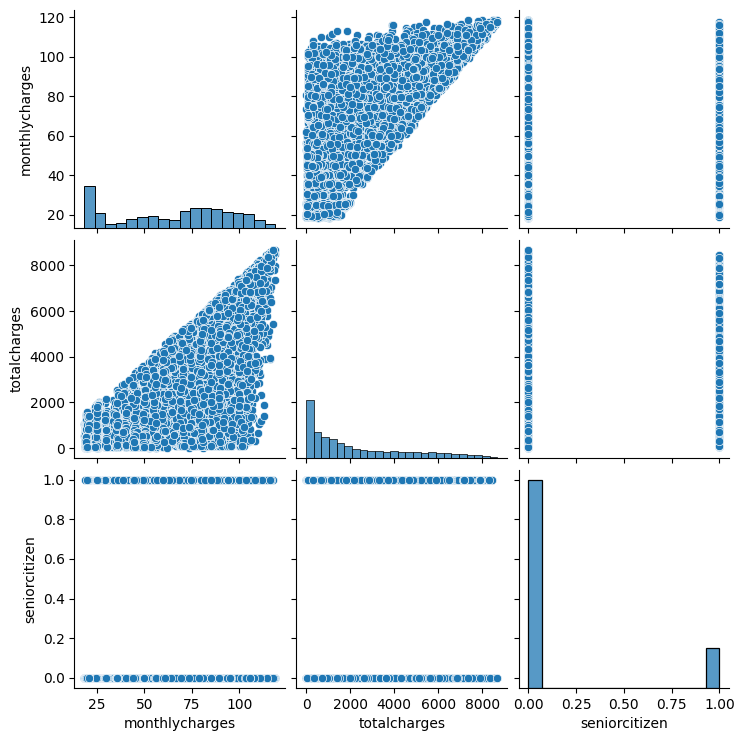

In [25]:
sns.pairplot(data)

No se observa una relacion directa entre las variables total charges y monthly charges. 

Text(0.5, 1.0, 'Balanceo de clase de cliente con contrato finalizado')

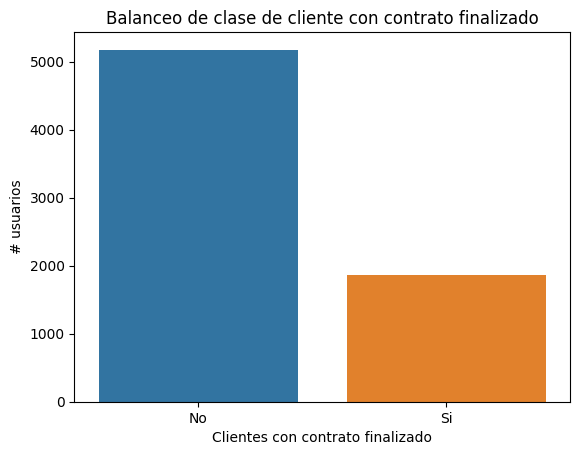

In [26]:
sns.countplot(data['enddate_new'])
plt.xlabel('Clientes con contrato finalizado')
plt.ylabel('# usuarios')
plt.title('Balanceo de clase de cliente con contrato finalizado')

Este grafica muestra claramente el desbalanceo de clases de la variable objetivo (enddate), hay una gran mayoria de clientes que siguen activos. Este desbalanceo se tratara para evitar afectar el resultados de los modelos.  

Text(0.5, 1.0, 'Balanceo de genero')

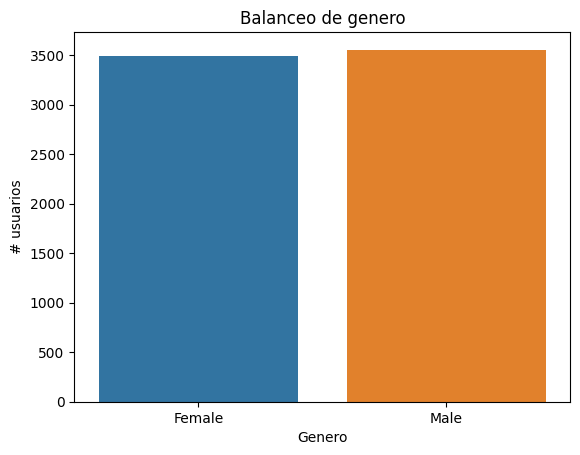

In [27]:
sns.countplot(data['gender'])
plt.xlabel('Genero')
plt.ylabel('# usuarios')
plt.title('Balanceo de genero')

Se nota un balanceo o reparticion pareja entre los generos femeninos y masculino que estan activos o estuvieron activos en la empresa.

Text(0.5, 1.0, 'Balanceo de servicios de internet')

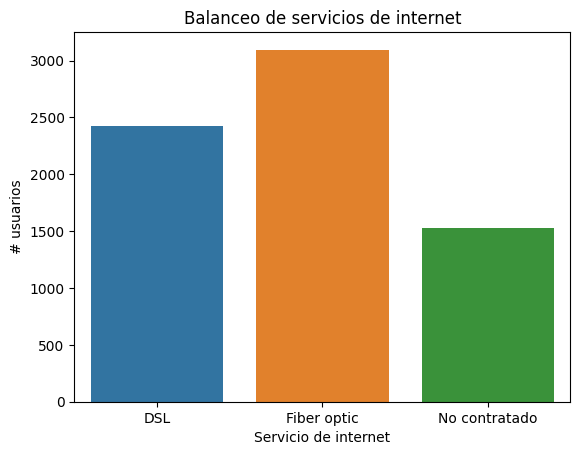

In [28]:
sns.countplot(data['internetservice'])
plt.xlabel('Servicio de internet')
plt.ylabel('# usuarios')
plt.title('Balanceo de servicios de internet')

Con esta grafica lo que se quiere observar es la tendencia en contratacion de servicios de internet, se observa que la gran mayoria tiene fibra optica y en menor cantidad esta la tecnologia DSL y en menor cantidad la gente no cuenta con ningun servicio de internet. 

Text(0.5, 1.0, 'Balanceo de servicios de telefonia')

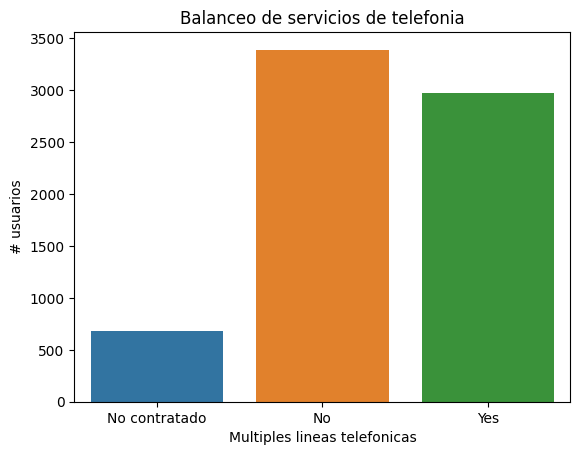

In [29]:
sns.countplot(data['multiplelines'])
plt.xlabel('Multiples lineas telefonicas')
plt.ylabel('# usuarios')
plt.title('Balanceo de servicios de telefonia')

Practicamente todos los clientes utilizan linea telefonica y lo que varia es la cantidad de lineas aunque esta ligeramente arriba aquellos que tienen solo una linea telefonica. 

Text(0.5, 1.0, 'Balanceo de contratos')

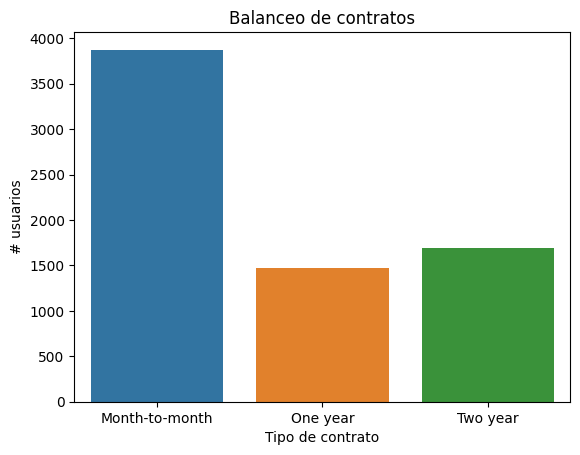

In [30]:
sns.countplot(data['type'])
plt.xlabel('Tipo de contrato')
plt.ylabel('# usuarios')
plt.title('Balanceo de contratos')

Existe una gran tendencia a tener contratos por mes y los contratos por 1 o 2 años estan muy equilibrados hacia abajo. 

Text(0.5, 1.0, 'Balanceo de streaming de TV')

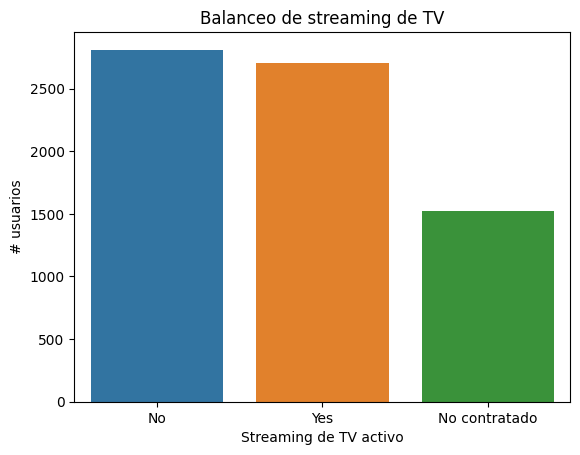

In [31]:
sns.countplot(data['streamingtv'])
plt.xlabel('Streaming de TV activo')
plt.ylabel('# usuarios')
plt.title('Balanceo de streaming de TV')

Text(0.5, 1.0, 'Balanceo de streaming de peliculas')

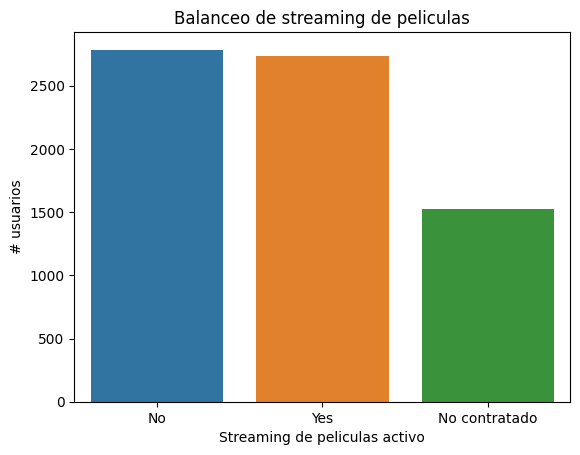

In [32]:
sns.countplot(data['streamingmovies'])
plt.xlabel('Streaming de peliculas activo')
plt.ylabel('# usuarios')
plt.title('Balanceo de streaming de peliculas')

Durante la exploracion de los dataset se observo una diferencia entre los datasets de contract vs internet y phone. Despues de realizar una exploracion de la informacion, se observo que muchos usuarios contratan uno u otro o bien los ambos, es por eso que no se puede eliminar esa informacion importante y se clasifico como No contratado. No se detecto una relacion total entre las variables numericas de monthly charge y total charge por lo que ambas de mantendran. 

Se observo un desbalanceo entre los clientes activos y los que no lo estan. En la siguiente seccion se trabajara en tecnicas para compensar ese desbalanceo y mejorar los modelos de prediccion. Primeramente se utilizara el balanceo que generan los modelos y dependiendo los resultados se decide si se utiliza alguna otra tecnica o se mantiene esa. 

## 2. Division dataset en entrenamiento y validacion, incluyendo One Hot Encoder y Label Encoder, asi como StandardScaler

## 2.1 Division normal

In [33]:
le_target = LabelEncoder()
target_encoded = le_target.fit_transform(data['enddate_new'])
print(target_encoded)
print(data['enddate_new'].head())
print(data['enddate_new'].tail())

[0 0 1 ... 0 1 0]
0    No
1    No
2    Si
3    No
4    Si
Name: enddate_new, dtype: object
7038    No
7039    No
7040    No
7041    Si
7042    No
Name: enddate_new, dtype: object


In [34]:
features = data.drop('enddate_new',axis=1)
target = target_encoded

print(target.shape)
print(features.shape)

(7043,)
(7043, 20)


In [35]:
features_train, features_test, target_train, target_test = train_test_split(features,target, test_size=0.3,random_state=42)

print(target_train.shape)
print(features_train.shape)
print(target_test.shape)
print(features_test.shape)

(4930,)
(4930, 20)
(2113,)
(2113, 20)


## 2.2 Division con OHE y StandardScaler

In [36]:
columns = ['type','paperlessbilling','paymentmethod','gender','seniorcitizen','partner','dependents','internetservice','onlinesecurity','onlinebackup','deviceprotection','techsupport','streamingtv','streamingmovies','multiplelines']

features_ohe = pd.get_dummies(features, columns=columns)

print(features_ohe.head(5))
features_ohe = features_ohe.drop(['customerid','begindate','enddate'],axis=1)

features_train_ohe, features_test_ohe, target_train, target_test = train_test_split(features_ohe,target, test_size=0.3,random_state=42)

scaler = StandardScaler()
features_train_ohe_scaled = scaler.fit_transform(features_train_ohe)
features_test_ohe_scaled = scaler.transform(features_test_ohe)

print(target_train.shape)
print(features_train_ohe.shape)
print(features_train_ohe_scaled.shape)
print(target_test.shape)
print(features_test_ohe.shape)
print(features_test_ohe_scaled.shape)

   customerid   begindate              enddate  monthlycharges  totalcharges  \
0  7590-VHVEG  2020-01-01                   No           29.85         29.85   
1  5575-GNVDE  2017-04-01                   No           56.95       1889.50   
2  3668-QPYBK  2019-10-01  2019-12-01 00:00:00           53.85        108.15   
3  7795-CFOCW  2016-05-01                   No           42.30       1840.75   
4  9237-HQITU  2019-09-01  2019-11-01 00:00:00           70.70        151.65   

   type_Month-to-month  type_One year  type_Two year  paperlessbilling_No  \
0                    1              0              0                    0   
1                    0              1              0                    1   
2                    1              0              0                    0   
3                    0              1              0                    1   
4                    1              0              0                    0   

   paperlessbilling_Yes  ...  techsupport_Yes  streaming

## 2.3 Division con Label Encoder y StandardScaler

In [37]:
features_le = features.copy()

label_encoders = {}

for col in columns:
    le = LabelEncoder()
    features_le[col] = le.fit_transform(features[col])
    label_encoders[col] = le  # Guardar para uso posterior

print(features_le.head())

features_le = features_le.drop(['customerid','begindate','enddate'],axis=1)
features_train_le, features_test_le, target_train, target_test = train_test_split(features_le,target, test_size=0.3,random_state=42)

scaler = StandardScaler()
features_train_le_scaled = scaler.fit_transform(features_train_le)
features_test_le_scaled = scaler.transform(features_test_le)

print(target_train.shape)
print(features_train_le.shape)
print(features_train_le_scaled.shape)
print(target_test.shape)
print(features_test_le.shape)
print(features_test_le_scaled.shape)

   customerid   begindate              enddate  type  paperlessbilling  \
0  7590-VHVEG  2020-01-01                   No     0                 1   
1  5575-GNVDE  2017-04-01                   No     1                 0   
2  3668-QPYBK  2019-10-01  2019-12-01 00:00:00     0                 1   
3  7795-CFOCW  2016-05-01                   No     1                 0   
4  9237-HQITU  2019-09-01  2019-11-01 00:00:00     0                 1   

   paymentmethod  monthlycharges  totalcharges  gender  seniorcitizen  \
0              2           29.85         29.85       0              0   
1              3           56.95       1889.50       1              0   
2              3           53.85        108.15       1              0   
3              0           42.30       1840.75       1              0   
4              2           70.70        151.65       0              0   

   partner  dependents  internetservice  onlinesecurity  onlinebackup  \
0        1           0                0    

## 3. Entrenamiento y resultados de modelos

In [41]:
def evaluate_model(model, train_features, train_target, test_features, test_target):

    eval_stats = {}

    # AGREGAR ESTAS LÍNEAS:
    train_pred = model.predict(train_features)
    test_pred = model.predict(test_features)

    fig, axs = plt.subplots(1, 2, figsize=(20, 6))

    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):

        eval_stats[type] = {}

        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]

        # F1
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]

        # ROC
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)
        eval_stats[type]['ROC AUC'] = roc_auc

        # PRC
        #precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        #aps = metrics.average_precision_score(target, pred_proba)
        #eval_stats[type]['APS'] = aps

        if type == 'train':
            color = 'blue'
        else:
            color = 'green'

        # Valor F1
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{type}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        # establecer cruces para algunos umbrales
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'Valor F1')

        # ROC
        ax = axs[1]
        ax.plot(fpr, tpr, color=color, label=f'{type}, ROC AUC={roc_auc:.2f}')
        # establecer cruces para algunos umbrales
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')
        ax.set_title(f'Curva ROC')

        # PRC
        #ax = axs[2]
        #ax.plot(recall, precision, color=color, label=f'{type}, AP={aps:.2f}')
        # establecer cruces para algunos umbrales
        #for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
        #    closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
        #    marker_color = 'orange' if threshold != 0.5 else 'red'
        #    ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        #ax.set_xlim([-0.02, 1.02])
        #ax.set_ylim([-0.02, 1.02])
        #ax.set_xlabel('recall')
        #ax.set_ylabel('precision')
        #ax.legend(loc='lower center')
        #ax.set_title(f'PRC')

        eval_stats[type]['Accuracy'] = metrics.accuracy_score(target, pred_target)
        eval_stats[type]['F1'] = metrics.f1_score(target, pred_target)

    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(2)
    df_eval_stats = df_eval_stats.reindex(index=('Accuracy', 'F1', 'ROC AUC'))

    print(df_eval_stats)

    print("Reporte de clasificacion - Entrenamiento")
    print(metrics.classification_report(train_target, train_pred))
    
    print("Reporte de clasificacion - Prueba")
    print(metrics.classification_report(test_target, test_pred))

    return

## 3.1 Dummy classifier

Se utilizara el modelo dummy para poder usarlo como referencia para los siguientes modelos. En este modelo no se utilizara ninguna tecnica de transformacion de datos, unicamente Label Encoder para la variable objetivo.

In [42]:
dummy_strategies = {
    'most_frequent': DummyClassifier(strategy='most_frequent'),
    'stratified': DummyClassifier(strategy='stratified'),
    'uniform': DummyClassifier(strategy='uniform'),
    'constant': DummyClassifier(strategy='constant',constant=1)
}

          train  test
Accuracy   0.74  0.73
F1         0.00  0.00
ROC AUC    0.50  0.50
Reporte de clasificacion - Entrenamiento
              precision    recall  f1-score   support

           0       0.74      1.00      0.85      3635
           1       0.00      0.00      0.00      1295

    accuracy                           0.74      4930
   macro avg       0.37      0.50      0.42      4930
weighted avg       0.54      0.74      0.63      4930

Reporte de clasificacion - Prueba
              precision    recall  f1-score   support

           0       0.73      1.00      0.84      1539
           1       0.00      0.00      0.00       574

    accuracy                           0.73      2113
   macro avg       0.36      0.50      0.42      2113
weighted avg       0.53      0.73      0.61      2113

          train  test
Accuracy   0.61  0.60
F1         0.26  0.28
ROC AUC    0.50  0.50
Reporte de clasificacion - Entrenamiento
              precision    recall  f1-score   support


/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1245: Und

          train  test
Accuracy   0.51  0.51
F1         0.35  0.36
ROC AUC    0.50  0.50
Reporte de clasificacion - Entrenamiento
              precision    recall  f1-score   support

           0       0.73      0.50      0.59      3635
           1       0.25      0.48      0.33      1295

    accuracy                           0.49      4930
   macro avg       0.49      0.49      0.46      4930
weighted avg       0.60      0.49      0.52      4930

Reporte de clasificacion - Prueba
              precision    recall  f1-score   support

           0       0.73      0.50      0.59      1539
           1       0.27      0.50      0.35       574

    accuracy                           0.50      2113
   macro avg       0.50      0.50      0.47      2113
weighted avg       0.60      0.50      0.53      2113

          train  test
Accuracy   0.26  0.27
F1         0.42  0.43
ROC AUC    0.50  0.50
Reporte de clasificacion - Entrenamiento
              precision    recall  f1-score   support


/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1245: Und

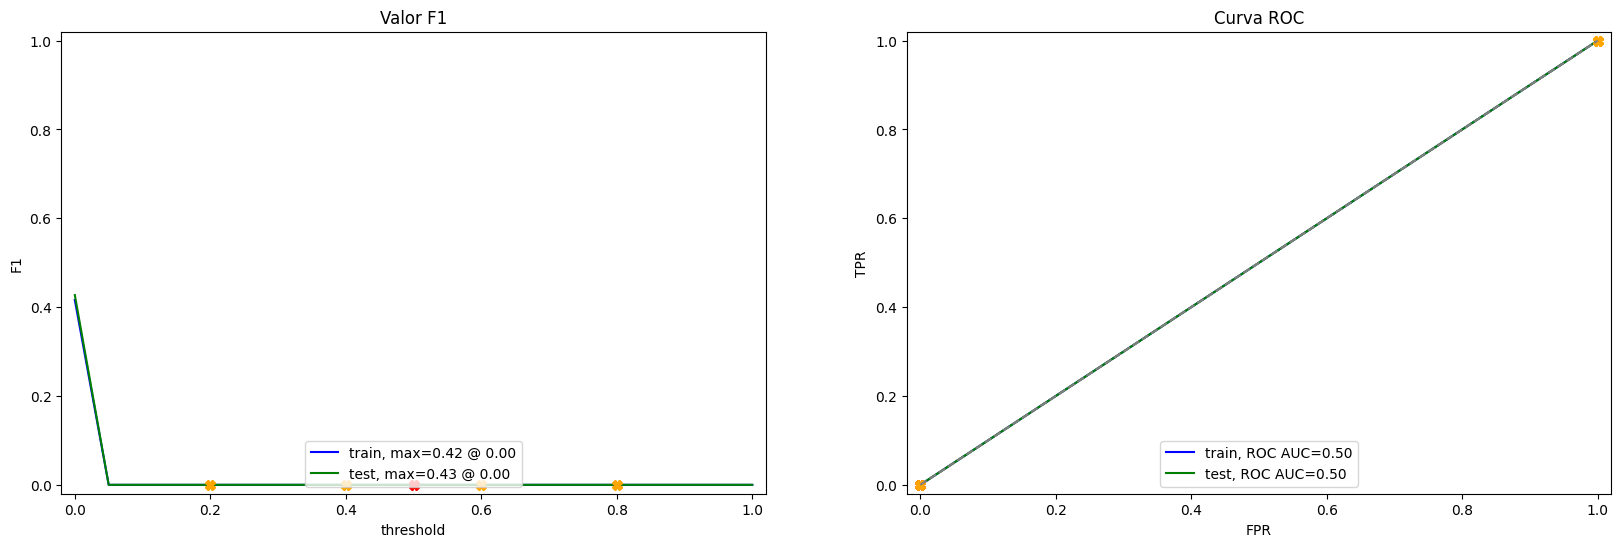

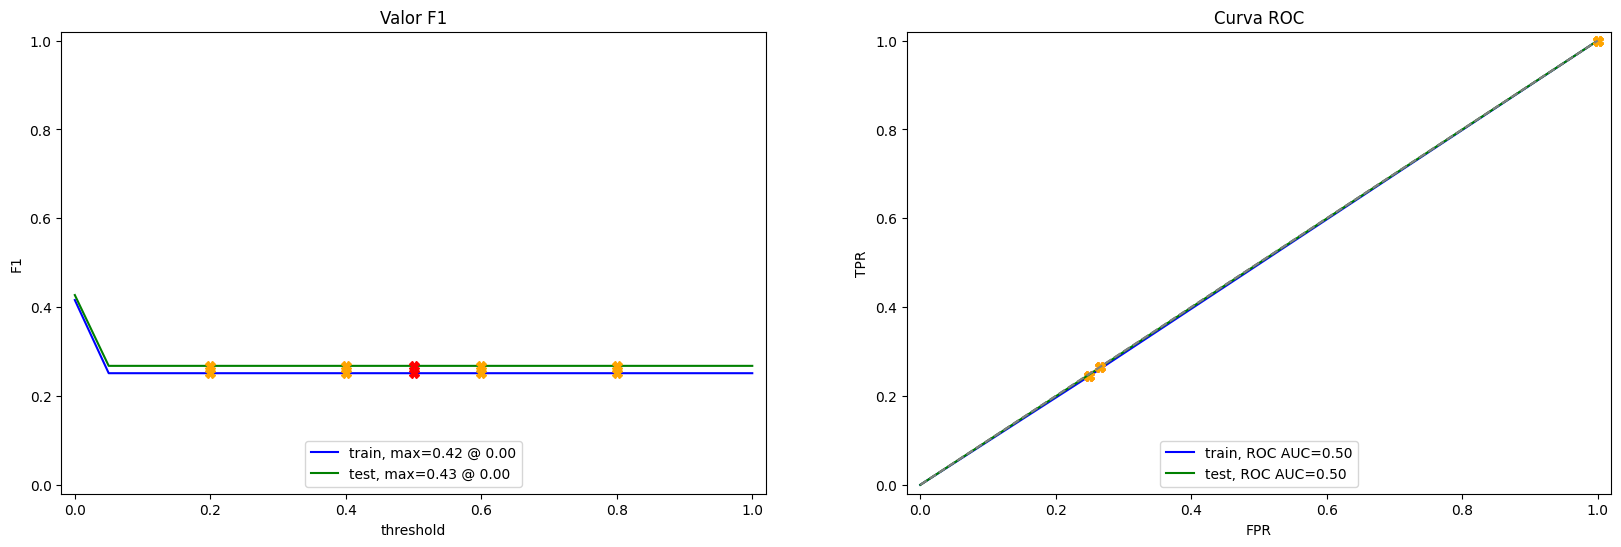

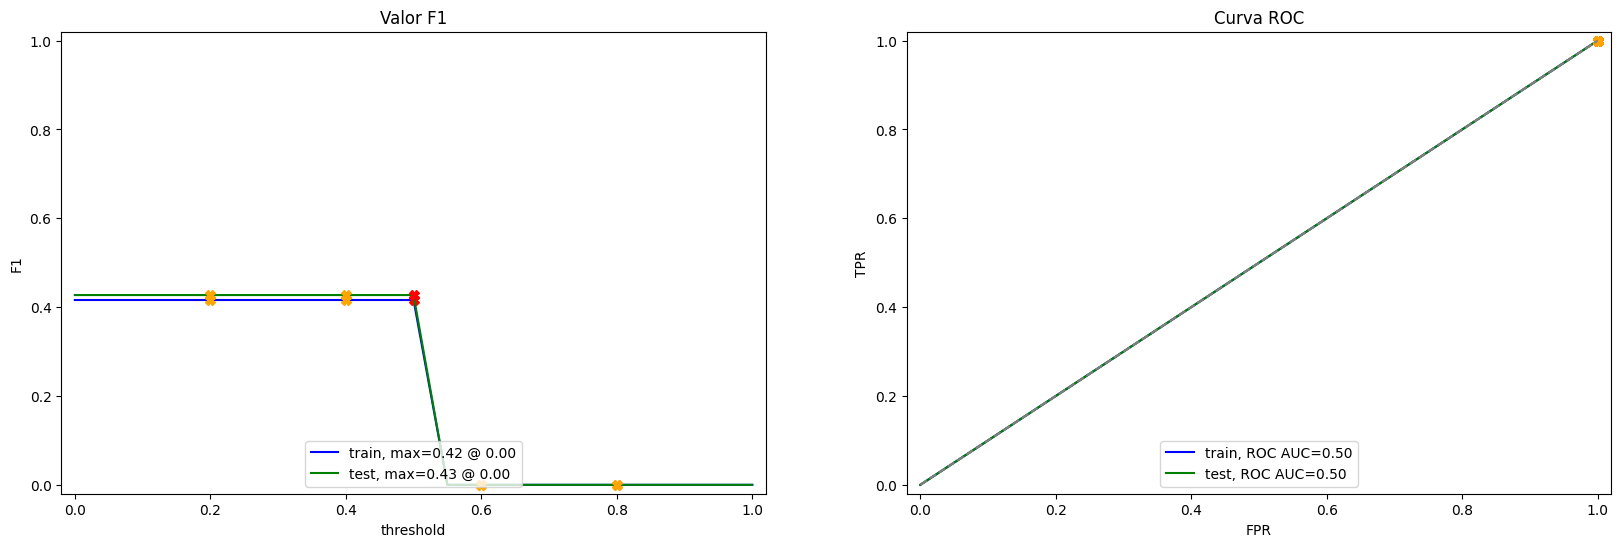

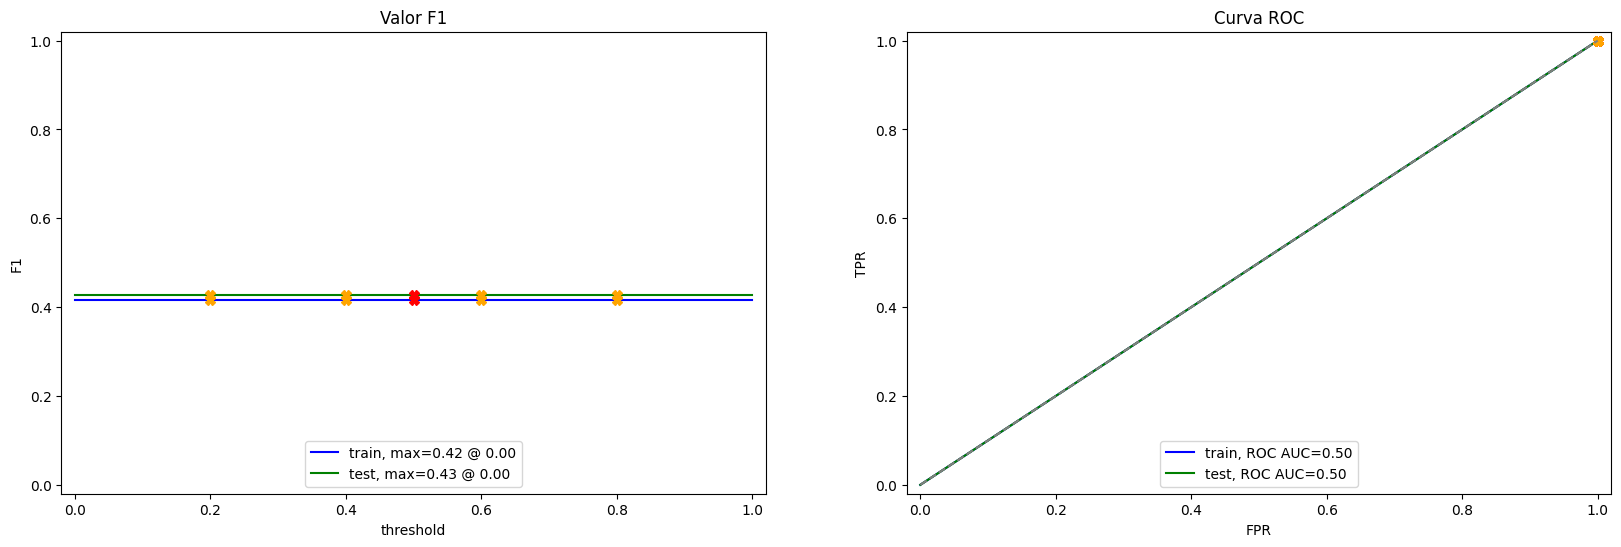

In [43]:
for name, model in dummy_strategies.items():
    model.fit(features_train, target_train)
    evaluate_model(model, features_train, target_train, features_test, target_test)

## 3.2 Logistic Regression

Para este modelo se aplicaran tecnicas de escalacion con StandardScaler y transformacion de datos con OHE.

In [44]:
logistic_params = {
    #'penalty': ['l1','l2','elasticnet'],
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear','lbfgs','saga','newton-cg'],
    'class_weight': [None,'balanced'],
    'max_iter': [200,500,1000,2000]    
}

lr = LogisticRegression()

grid_lr = GridSearchCV(
    estimator=lr,
    param_grid=logistic_params,
    cv=5,
    scoring='f1',
    n_jobs=1,
    verbose=1    
)

grid_lr.fit(features_train_ohe_scaled,target_train)


print("Mejores parámetros:", grid_lr.best_params_) 
print("Mejor score en entrenamiento:", grid_lr.best_score_)

Fitting 5 folds for each of 160 candidates, totalling 800 fits


/.venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:328: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn("The max_iter was reached which means "
/.venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:328: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn("The max_iter was reached which means "
/.venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:328: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn("The max_iter was reached which means "
/.venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:328: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn("The max_iter was reached which means "
/.venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:328: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.

Mejores parámetros: {'C': 1, 'class_weight': 'balanced', 'max_iter': 200, 'solver': 'lbfgs'}
Mejor score en entrenamiento: 0.6072353158104736


          train  test
Accuracy   0.74  0.75
F1         0.61  0.64
ROC AUC    0.84  0.85
Reporte de clasificacion - Entrenamiento
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      3635
           1       0.50      0.79      0.61      1295

    accuracy                           0.74      4930
   macro avg       0.70      0.75      0.71      4930
weighted avg       0.80      0.74      0.75      4930

Reporte de clasificacion - Prueba
              precision    recall  f1-score   support

           0       0.92      0.72      0.81      1539
           1       0.53      0.82      0.64       574

    accuracy                           0.75      2113
   macro avg       0.72      0.77      0.73      2113
weighted avg       0.81      0.75      0.76      2113



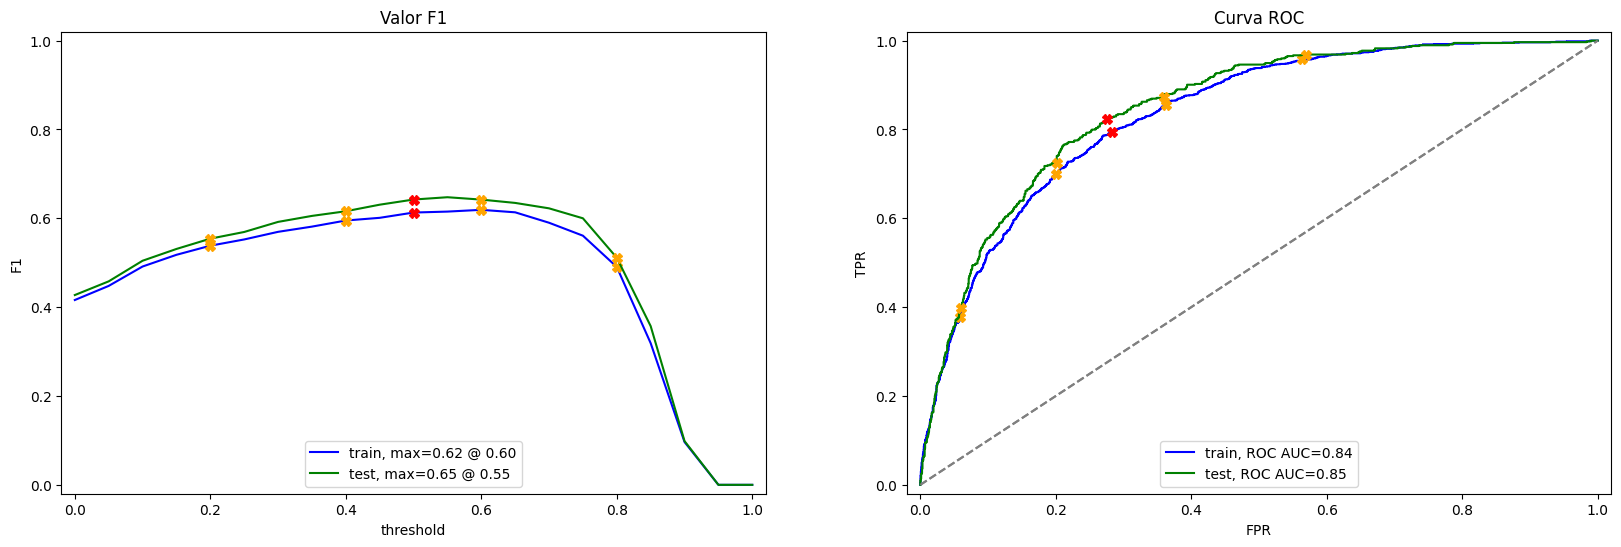

In [45]:
best_lr = grid_lr.best_estimator_
evaluate_model(best_lr, features_train_ohe_scaled, target_train,features_test_ohe_scaled, target_test)

## 3.3 Decision Tree Classifier

En este modelo se utilizara escalacion con StandardScaler y OHE, asi como varios hiperparametros para seleccionar el que mejor se comporta con la metrica F1 para una vez seleccionado el mejor, se obtengan las metricas con el dataset de prueba. 

In [46]:
dt_params = {
    'criterion': ['gini','entropy'],
    'splitter': ['best','random'],
    'max_depth': [1,5,10,15,20,40,50,100,200,500],
    'min_samples_split': [2,10,20,50,100],
    'min_samples_leaf': [1,5,10,20,40,100],
    'max_features': ['sqrt','log2',None],
    'class_weight': [None,'balanced'],
    'random_state': [42]
}

dt = DecisionTreeClassifier()

grid_dt = RandomizedSearchCV(
    estimator=dt,
    param_distributions=dt_params,
    n_iter=100,
    cv=5,
    scoring='f1',
    n_jobs=1,
    verbose=1,
    random_state=42
)

grid_dt.fit(features_train_ohe_scaled,target_train)


print("Mejores parámetros:", grid_dt.best_params_) 
print("Mejor score en entrenamiento:", grid_dt.best_score_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Mejores parámetros: {'splitter': 'best', 'random_state': 42, 'min_samples_split': 10, 'min_samples_leaf': 40, 'max_features': None, 'max_depth': 20, 'criterion': 'gini', 'class_weight': 'balanced'}
Mejor score en entrenamiento: 0.6066833018037577


          train  test
Accuracy   0.77  0.74
F1         0.65  0.63
ROC AUC    0.87  0.84
Reporte de clasificacion - Entrenamiento
              precision    recall  f1-score   support

           0       0.92      0.74      0.82      3635
           1       0.54      0.83      0.65      1295

    accuracy                           0.77      4930
   macro avg       0.73      0.79      0.74      4930
weighted avg       0.82      0.77      0.78      4930

Reporte de clasificacion - Prueba
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1539
           1       0.52      0.80      0.63       574

    accuracy                           0.74      2113
   macro avg       0.71      0.76      0.72      2113
weighted avg       0.80      0.74      0.76      2113



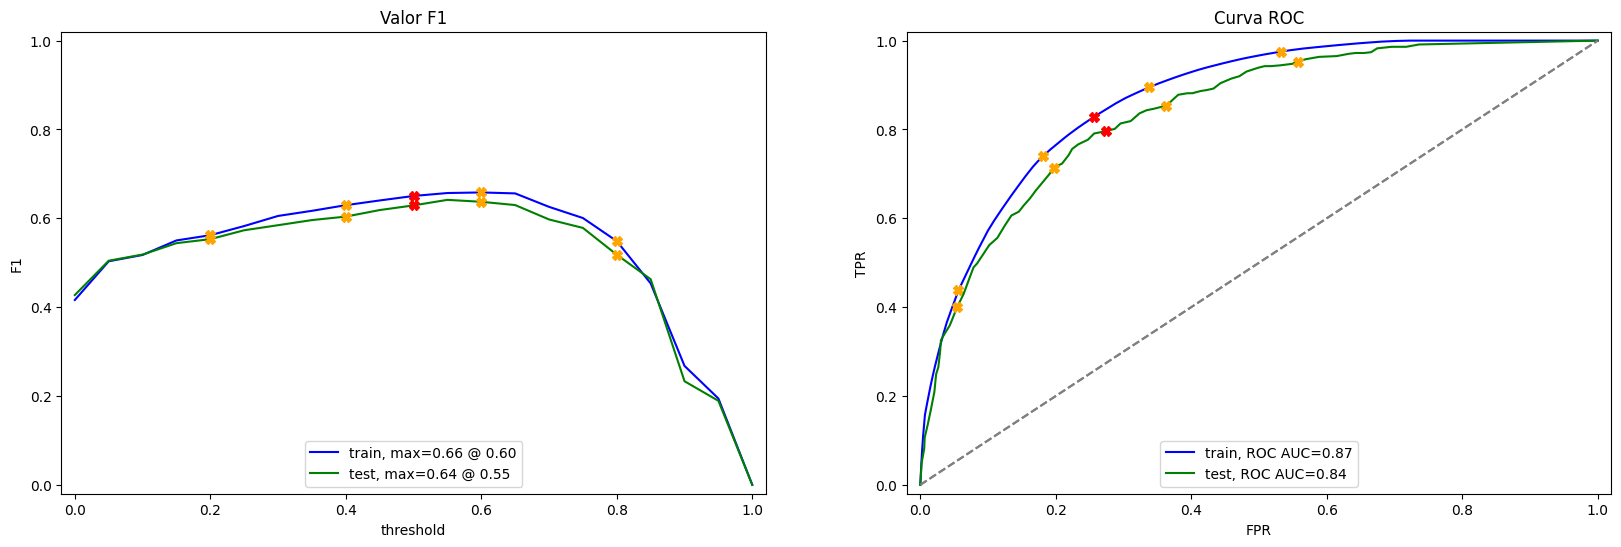

In [47]:
best_dt = grid_dt.best_estimator_
evaluate_model(best_dt, features_train_ohe_scaled, target_train,features_test_ohe_scaled, target_test)

## 3.4 Random Forest Classifier

En este modelo se utilizara escalacion con StandardScaler y LabelEncoder, asi como varios hiperparametros para seleccionar el que mejor se comporta con la metrica F1 para una vez seleccionado el mejor, se obtengan las metricas con el dataset de prueba. 

In [48]:
rf_params = {
    'n_estimators': [10,20,50,100,200,300,500],
    'criterion': ['gini','entropy'],
    'max_depth': [1,5,10,15,20,40,50,100,200,500,None],
    'min_samples_split': [2,10,20,50,100],
    'min_samples_leaf': [1,5,10,20,40,100],
    'max_features': ['sqrt','log2',None],
    'class_weight': [None,'balanced'],
    'bootstrap': [True,False],
    'random_state': [42]
}

rf = RandomForestClassifier()

grid_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_params,
    n_iter=100,
    cv=5,
    scoring='f1',
    n_jobs=1,
    verbose=1,
    random_state=42
)

grid_rf.fit(features_train_le_scaled,target_train)


print("Mejores parámetros:", grid_rf.best_params_) 
print("Mejor score en entrenamiento:", grid_rf.best_score_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Mejores parámetros: {'random_state': 42, 'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 15, 'criterion': 'gini', 'class_weight': 'balanced', 'bootstrap': True}
Mejor score en entrenamiento: 0.6252793363395417


          train  test
Accuracy   0.86  0.79
F1         0.76  0.66
ROC AUC    0.94  0.86
Reporte de clasificacion - Entrenamiento
              precision    recall  f1-score   support

           0       0.95      0.85      0.90      3635
           1       0.67      0.87      0.76      1295

    accuracy                           0.86      4930
   macro avg       0.81      0.86      0.83      4930
weighted avg       0.88      0.86      0.86      4930

Reporte de clasificacion - Prueba
              precision    recall  f1-score   support

           0       0.90      0.80      0.85      1539
           1       0.58      0.75      0.66       574

    accuracy                           0.79      2113
   macro avg       0.74      0.78      0.75      2113
weighted avg       0.81      0.79      0.79      2113



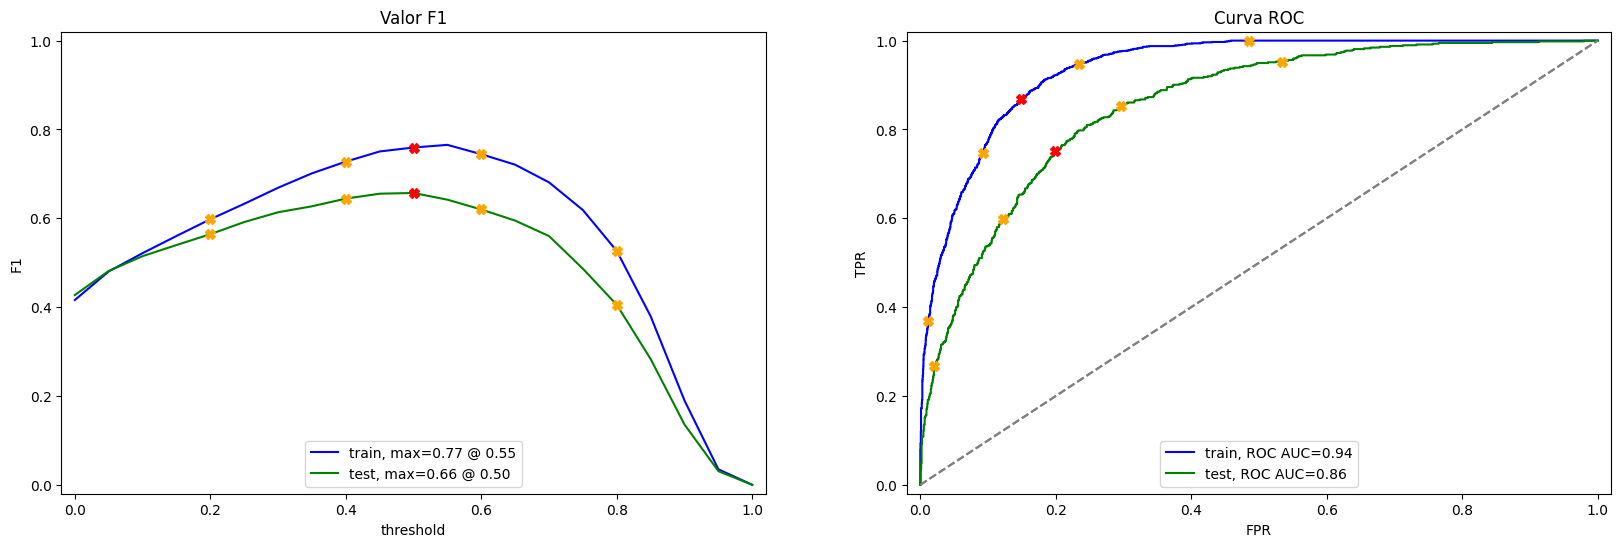

In [49]:
best_rf = grid_rf.best_estimator_
evaluate_model(best_rf, features_train_le_scaled, target_train,features_test_le_scaled, target_test)

Durante el entrenamiento de modelos(Logistic Regression, Decision Tree Classifier y Random Forest Classifier), se fue observando el valor de la metrica F1, asi como seleccionando los mejores hiperparametros para poder utilizar el dataset de prueba y obtener los resultados finales de ambos datasets. Se opto por finalizar el entrenamiento de modelos una vez que obtuvo la metrica objetivo del 0.88 o mayor, la cual se cumple con el modelo de Random Forest Classifier.

## 4. Tasa de cancelacion de clientes

In [50]:
predicciones_rf = best_rf.predict(features_test_le_scaled)

tasa_cancelacion_pronosticada = (predicciones_rf == 1).sum() / len(predicciones_rf) * 100

print(f"Tasa de cancelación pronosticada por Random Forest: {tasa_cancelacion_pronosticada:.2f}%")
print(f"Clientes que el modelo predice que cancelarán: {(predicciones_rf == 1).sum()}")
print(f"Total de clientes en test: {len(predicciones_rf)}\n")

tasa_real_test = (target_test == 1).sum() / len(target_test) * 100

print(f"Tasa real de cancelación en test: {tasa_real_test:.2f}%")
print(f"Tasa pronosticada por el modelo: {tasa_cancelacion_pronosticada:.2f}%")
print(f"Diferencia: {abs(tasa_real_test - tasa_cancelacion_pronosticada):.2f} puntos porcentuales")

Tasa de cancelación pronosticada por Random Forest: 34.93%
Clientes que el modelo predice que cancelarán: 738
Total de clientes en test: 2113

Tasa real de cancelación en test: 27.17%
Tasa pronosticada por el modelo: 34.93%
Diferencia: 7.76 puntos porcentuales


SERVICIOS DE CLIENTES QUE SE PREDICE QUE CANCELARÁN 



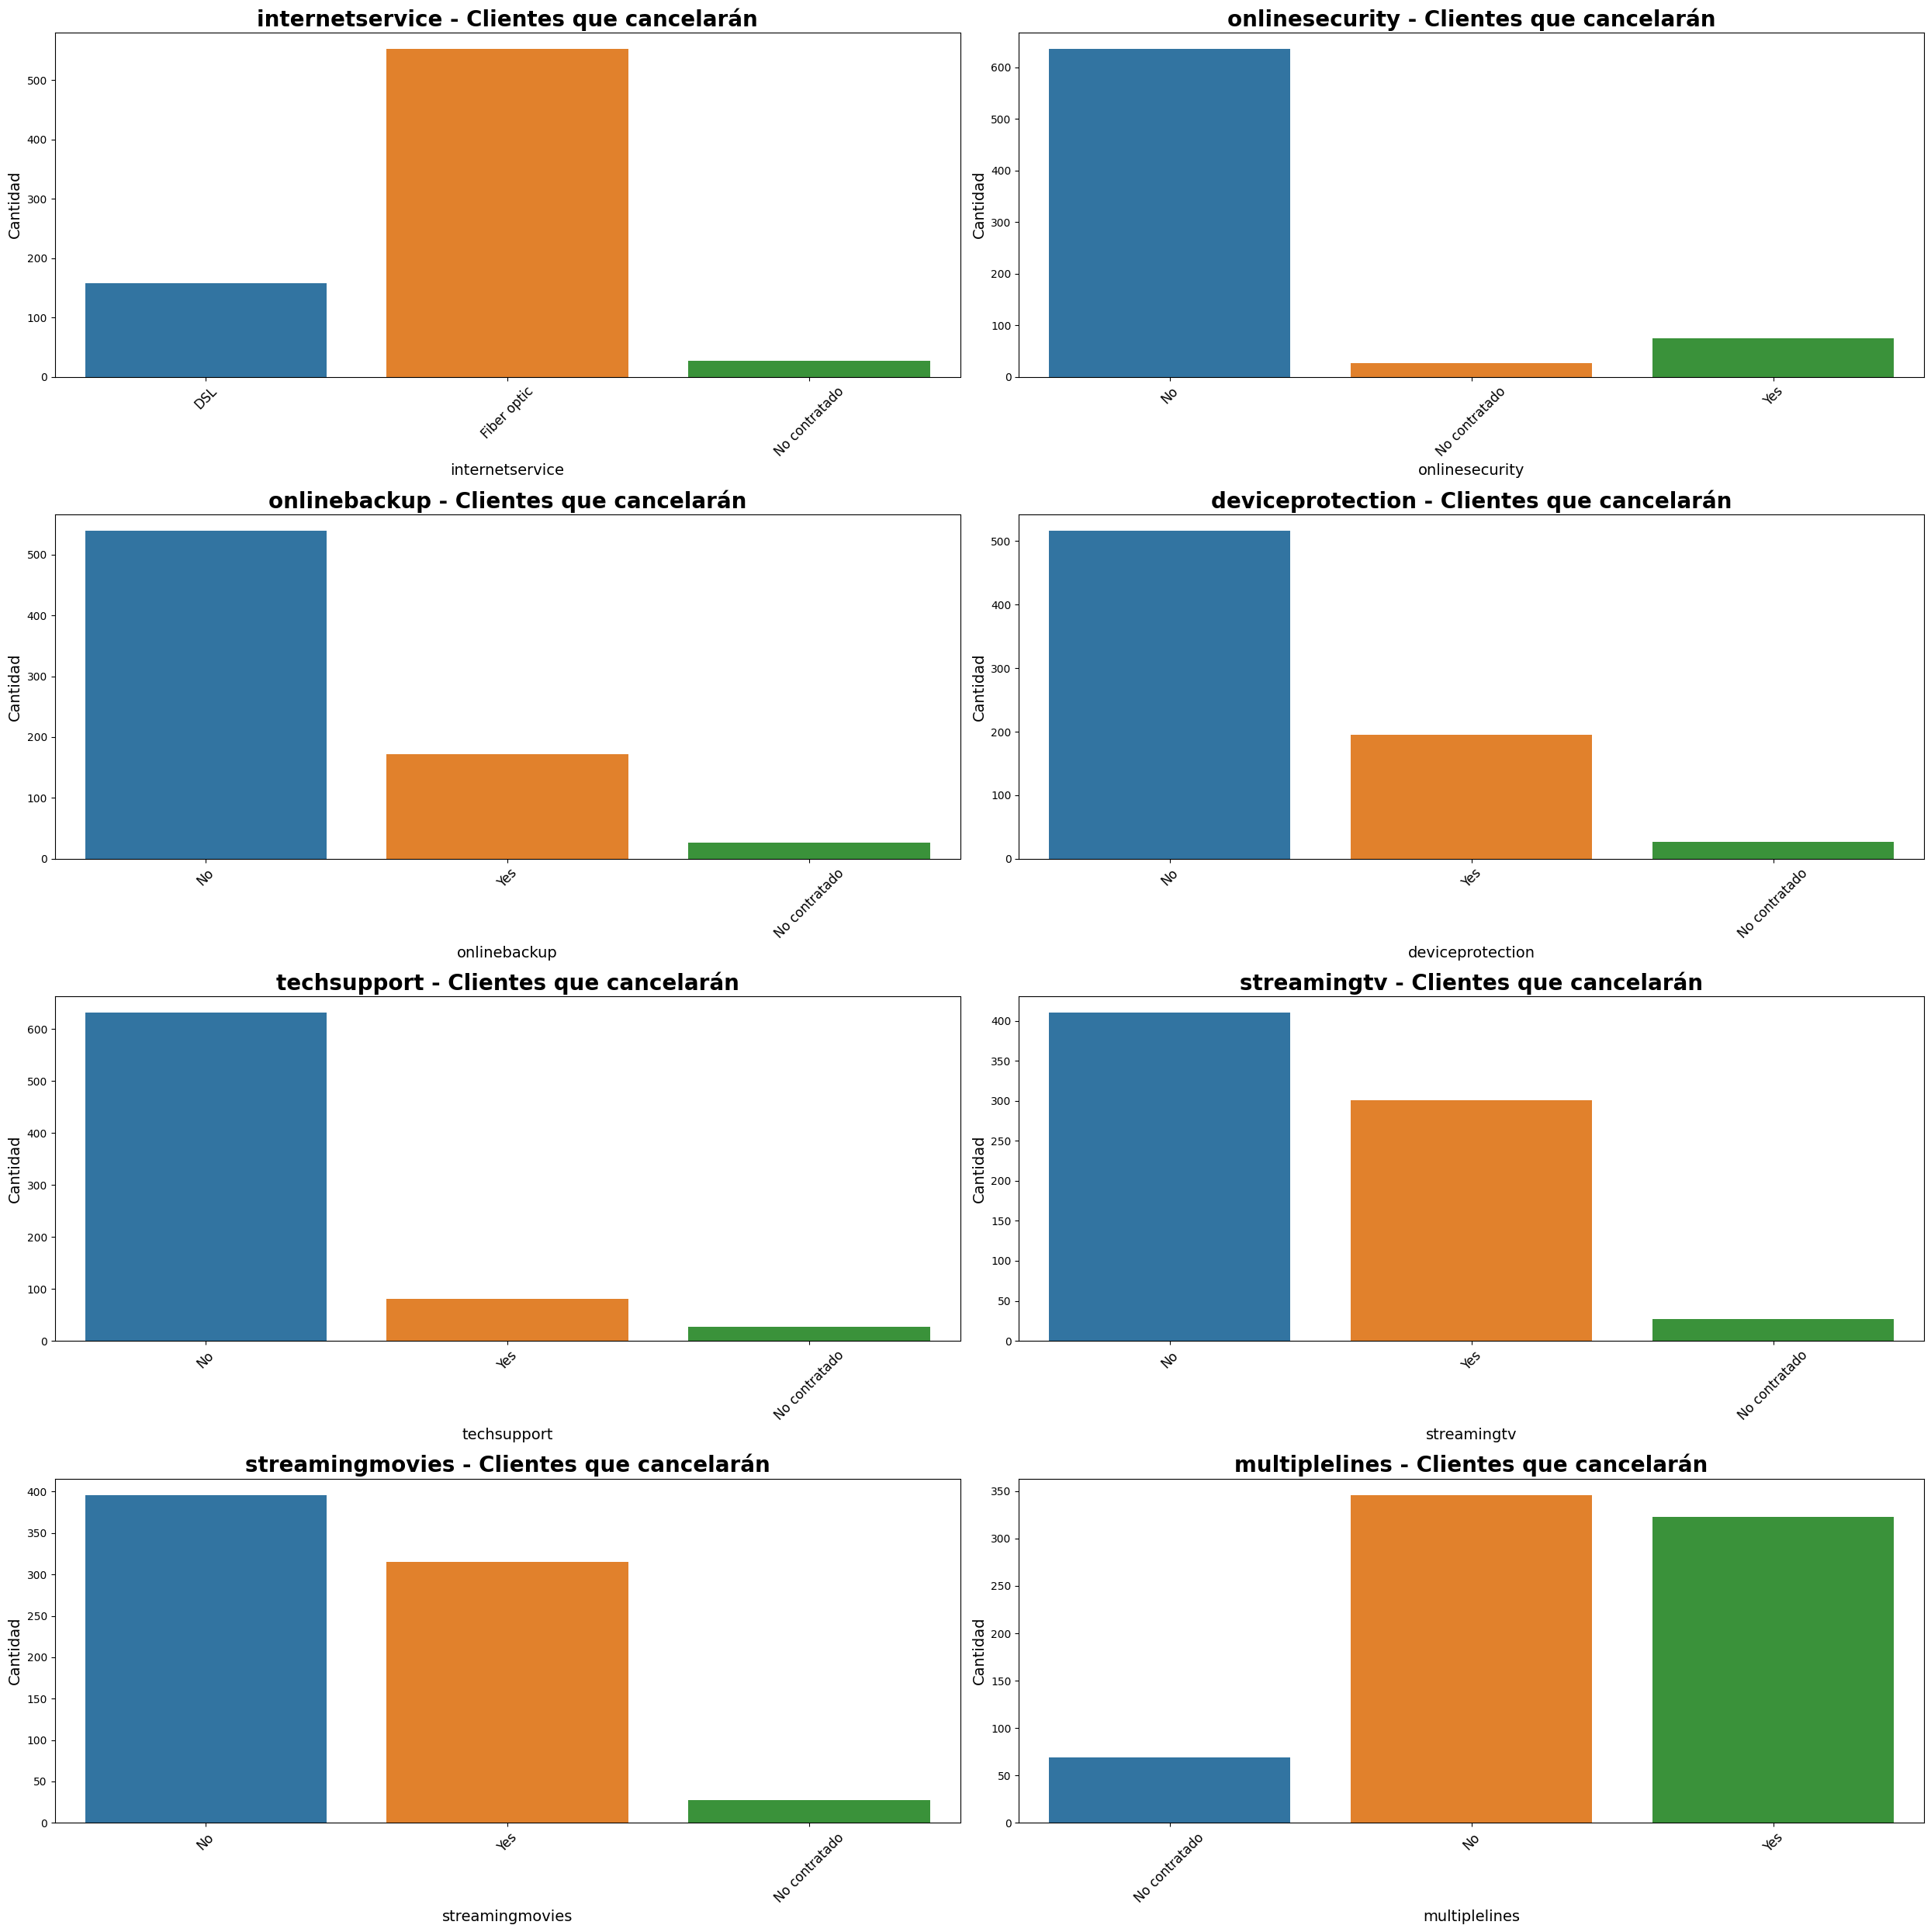

In [51]:
indices_cancelaran = np.where(predicciones_rf == 1)[0]

indices_originales_test = features_test_le.index

clientes_predichos_cancelar = data.loc[indices_originales_test[indices_cancelaran]].copy()

service_cols = ['internetservice', 'onlinesecurity', 'onlinebackup', 
                  'deviceprotection', 'techsupport', 'streamingtv', 
                  'streamingmovies', 'multiplelines']

print("SERVICIOS DE CLIENTES QUE SE PREDICE QUE CANCELARÁN \n")

fig, axes = plt.subplots(4, 2, figsize=(25, 25))
axes = axes.flatten()

for i, servicio in enumerate(service_cols):  # Cambiar servicios_cols por service_cols
    sns.countplot(data=clientes_predichos_cancelar, x=servicio, ax=axes[i])
    axes[i].set_title(f'{servicio} - Clientes que cancelarán',fontsize=20,fontweight='bold')
    axes[i].set_xlabel(servicio, fontsize=14)
    axes[i].set_ylabel('Cantidad', fontsize=14)
    axes[i].tick_params(axis='x', rotation=45,labelsize=12)
    axes[i].tick_params(axis='x', rotation=45,labelsize=12)

plt.tight_layout()
plt.show()

Dentro del analisis de la tasa de cancelacion de clientes predichas por el modelo de Random Forest, se oservo que el modelo obtuvo una tasa aproximada de 35% vs la real de 27%, lo que hace que el modelo este por arriba del real en un 8% aproximadamente. Posteriormente se verificaron los servicios que se dejaran de tener por esos clientes que cancelan, quedando de la siguiente manera:
1. El servicio de internet de fibra optica
2. El servicio de lineas telefonicas(multiples o simples)
3. El servicio de streaming tv y de peliculas

## 5. Conclusiones generales

Los resultados obtenidos fueron los siguientes:

**Dummy Classifier:**

La estrategia que mejor se comporto fue la constante con valor de 1 y esto debido a que mantuvo un ROC de 0.50 en ambos datasets, F1 fue de 0.43 practicamente, accuracy fue 0.26 para entrenamiento y 0.27 para prueba. Esto se uso de referencia para entrenar los siguientes modelos.
 
**Logistic Regression:**

Los hiperparametros que mejor funcionaron fueron el solver lbfgs, C de 1, obviamente la clase balanceada y maximo de iteracion de 200 y esto debido a que mantuvo un ROC de 0.84 para entrenamiento y 0.85 para prueba, F1 fue de 0.61 para entrenamiento y 0.64 para prueba, accuracy fue 0.74 para entrenamiento y 0.75 para prueba. Se observo una mejora significativa con respecto al modelo dummy pero aun fuera de que se busca para este negocio o proyecto. Se observo que el modelo puede detectar mas facilmente los clientes que se mantienen con servicio en la empresa a los que se van.

**Decision Tree Classifier:**

Los hiperparametros que mejor funcionaron fueron splitter: best, el minimo de muestras para dividir un nodo de 10, el minimo de muestras en una hoja de 40, numero de caracteristicas consideradas para cada division: Ninguna, profundidad maxima del arbol de 20, la funcion para media la calidad de la division fue gini y obviamente la clase balanceada. Esto mantuvo un ROC de 0.87 para entrenamiento y 0.84 para prueba, F1 fue de 0.65 para entrenamiento y 0.63 para prueba, accuracy fue 0.77 para entrenamiento y 0.74 para prueba. Se observo una mejora significativa en las metricas pero aun el modelo batalla para poder identificar los clientes que se van de la empresa, los que se mantienen mejora mucho la identificacion.

**Random Forest Classifier:**

Los hiperparametros que mejor funcionaron fueron splitter: numero de arboles en el bosque de 100, minimo de muestras para dividir un nodo de 10, minimo de muestras en la hoja de 5, numero de caracteristicas consideradas en cada division es sqrt, profundidad maxima de cada arbol de 15, la funcion para media la calidad de la division fue gini y obviamente la clase balanceada. Esto mantuvo un ROC de 0.94 para entrenamiento y 0.86 para prueba, F1 fue de 0.76 para entrenamiento y 0.66 para prueba, accuracy fue 0.86 para entrenamiento y 0.79 para prueba. Se observo una mejora en la identificacion de clientes que van de la empresa en el entrenamiento pero en la de prueba bajo ese porcentaje.

Dado el analisis anterior el modelo que mejor se comporto en terminos generales fue el Random Forest Classifier, es por eso que esa es la eleccion para la prediccion de los clientes de este proyecto, esta empresa y con estos datasets.

De igual manera se utilizaron los resultados del modelo para poder obtener la tasa de cancelacion real vs la del modelo, obtenido lo siguiente:

El modelo Random Forest Classifier obtuvo una tasa de prediccion aproximada de 35% vs la real de 27%, lo que hace que el modelo este por arriba del real en un 8% aproximadamente. Posteriormente se verificaron los servicios que se dejaran de tener por esos clientes que cancelan, quedando de la siguiente manera:

1. El servicio de internet de fibra optica
2. El servicio de lineas telefonicas(multiples o simples)
3. El servicio de streaming tv y de peliculas
